# MathEBT — training metrics dashboard

Reads `metrics.jsonl` (written by `DinoTrainer._log`) and `eval.json` (written by `scripts/eval_all.py`) and reproduces the checks we've been doing by hand: reset detection, entropy/max_prob collapse watch, and the gate table.

**Reset detection matters here**: every time `total_steps`/`warmup_steps`/etc. get edited and training resumes from a checkpoint, the `step` counter can jump backward (resume) while the *schedule* recomputes from the new config — `lr`/`weight_decay` can visibly jump even though `step` doesn't reset. This notebook flags both kinds of discontinuity rather than silently plotting through them as if it were one continuous run.

In [1]:
# Uncomment if pandas/matplotlib aren't already installed in this environment
# %pip install -q pandas matplotlib

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- paths: edit these ---
METRICS_PATH = "metrics-14.jsonl"   # e.g. outputs/dino_v0_certified/metrics.jsonl
EVAL_PATHS = ["eval.json"]       # list multiple eval.json snapshots (e.g. from different checkpoints) to compare their gate progress over time

## Load + reset detection

In [3]:
def load_metrics(path: str) -> pd.DataFrame:
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


def find_resets(df: pd.DataFrame) -> list[int]:
    """Row indices where `step` drops to <= the previous row's step -- a resume
    from an earlier checkpoint (possibly with a different config, given lr/wd can
    also jump without a step reset -- see the schedule-discontinuity check below)."""
    resets = []
    prev = None
    for i, s in enumerate(df["step"]):
        if prev is not None and s <= prev:
            resets.append(i)
        prev = s
    return resets


def find_schedule_jumps(df: pd.DataFrame, col: str = "lr", rel_thresh: float = 3.0) -> list[int]:
    """Row indices where `col` jumps by more than `rel_thresh`x from one logged
    point to the next, without a step reset -- catches a total_steps/warmup_steps
    edit that changed the schedule mid-run (the step counter kept climbing, but the
    cosine curve it's being read from moved)."""
    jumps = []
    vals = df[col].to_numpy()
    for i in range(1, len(vals)):
        a, b = vals[i - 1], vals[i]
        if min(a, b) <= 0:
            continue
        if max(a, b) / min(a, b) > rel_thresh:
            jumps.append(i)
    return jumps


df = load_metrics(METRICS_PATH)
resets = find_resets(df)
jumps = [i for i in find_schedule_jumps(df, "lr") if i not in resets]

print(f"{len(df)} records, step {df['step'].iloc[0]} -> {df['step'].iloc[-1]}")
print(f"{len(resets)} step reset(s) (resume from checkpoint): rows {resets}")
print(f"{len(jumps)} schedule jump(s) without a step reset (config changed mid-run): rows {jumps}")

nan_rows = df[df.isna().any(axis=1)]
if len(nan_rows):
    print(f"WARNING: {len(nan_rows)} rows contain NaN")
else:
    print("no NaN/missing values")

2043 records, step 0 -> 19990
3 step reset(s) (resume from checkpoint): rows [3, 25, 144]
7 schedule jump(s) without a step reset (config changed mid-run): rows [1, 4, 23, 26, 343, 543, 743]
no NaN/missing values


In [4]:
# The continuous segment since the LAST reset -- the run that's actually still
# in progress. Everything below plots this segment by default; flip to `df` for
# the full history including superseded attempts.
final = df.iloc[resets[-1]:].reset_index(drop=True) if resets else df
print(f"final continuous segment: step {final['step'].iloc[0]} -> {final['step'].iloc[-1]} ({len(final)} records)")

final continuous segment: step 1010 -> 19990 (1899 records)


## Collapse watch: teacher entropy + max_prob

The two numbers docs/DESIGN.md flags as the earliest collapse signal (§11). Dashed lines are the `gates.py` thresholds (`entropy_mean > 0.5`, `max_prob < 0.95`) -- but the real risk zone is well before you'd ever hit those; watch the *trend*, not just whether you're still above/below the line.

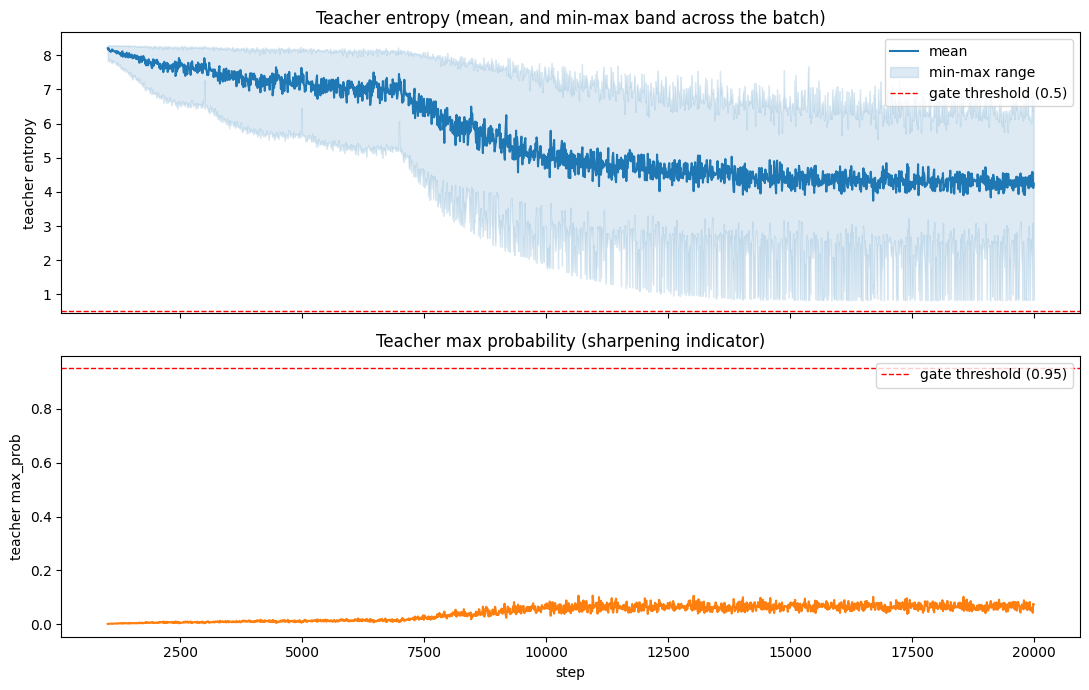

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
ax.plot(final["step"], final["teacher_entropy_mean"], label="mean", color="C0")
ax.fill_between(final["step"], final["teacher_entropy_min"], final["teacher_entropy_max"],
                 alpha=0.15, color="C0", label="min-max range")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="gate threshold (0.5)")
ax.set_ylabel("teacher entropy")
ax.legend(loc="upper right")
ax.set_title("Teacher entropy (mean, and min-max band across the batch)")

ax = axes[1]
ax.plot(final["step"], final["teacher_max_prob"], color="C1")
ax.axhline(0.95, color="red", linestyle="--", linewidth=1, label="gate threshold (0.95)")
ax.set_ylabel("teacher max_prob")
ax.set_xlabel("step")
ax.legend(loc="upper right")
ax.set_title("Teacher max probability (sharpening indicator)")

plt.tight_layout()
plt.show()

## Loss, schedules

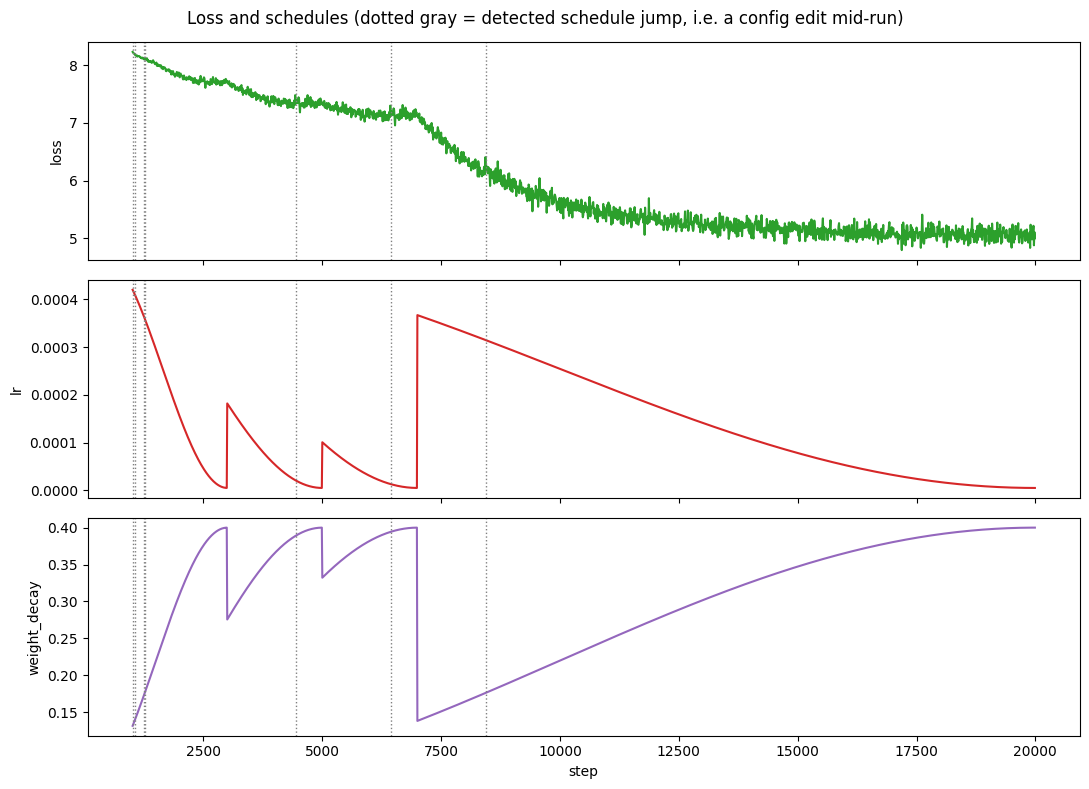

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(final["step"], final["loss"], color="C2")
axes[0].set_ylabel("loss")

axes[1].plot(final["step"], final["lr"], color="C3")
axes[1].set_ylabel("lr")

axes[2].plot(final["step"], final["weight_decay"], color="C4")
axes[2].set_ylabel("weight_decay")
axes[2].set_xlabel("step")

for i in jumps:
    row_step = final["step"].iloc[i] if i < len(final) else None
    if row_step is not None:
        for ax in axes:
            ax.axvline(row_step, color="gray", linestyle=":", linewidth=1)

plt.suptitle("Loss and schedules (dotted gray = detected schedule jump, i.e. a config edit mid-run)")
plt.tight_layout()
plt.show()

## Representation health: collapse vs. diversity

`cos_random_pairs` -> 1 means the raw backbone latent is collapsing onto a single point, independent of the DINO loss value. `latent_variance` collapsing to 0 is the same failure seen from a different angle.

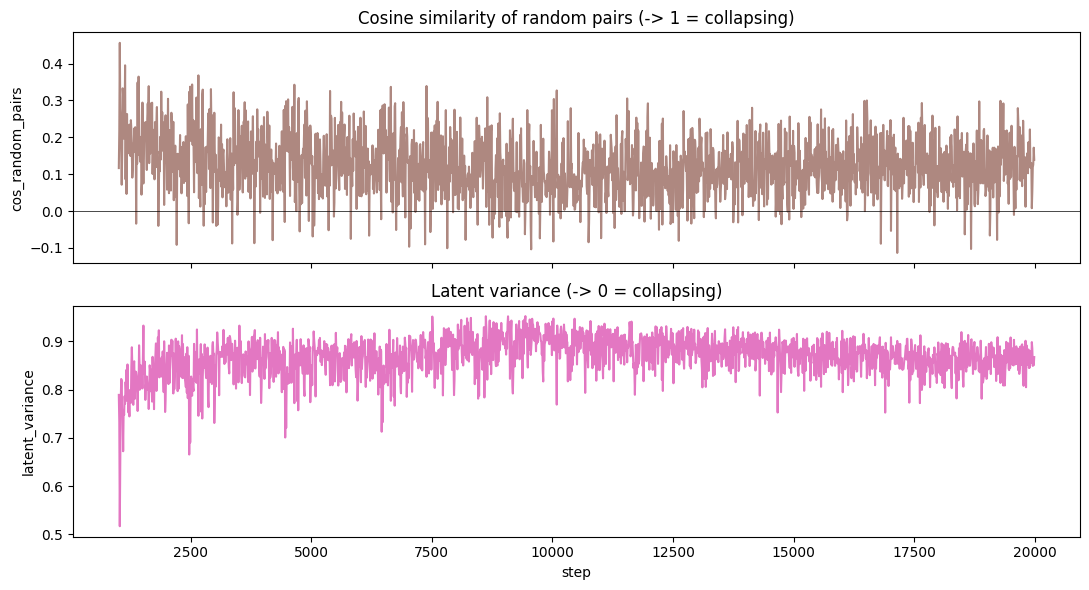

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(final["step"], final["cos_random_pairs"], color="C5", alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("cos_random_pairs")
axes[0].set_title("Cosine similarity of random pairs (-> 1 = collapsing)")

axes[1].plot(final["step"], final["latent_variance"], color="C6")
axes[1].set_ylabel("latent_variance")
axes[1].set_xlabel("step")
axes[1].set_title("Latent variance (-> 0 = collapsing)")

plt.tight_layout()
plt.show()

## Gradients + center

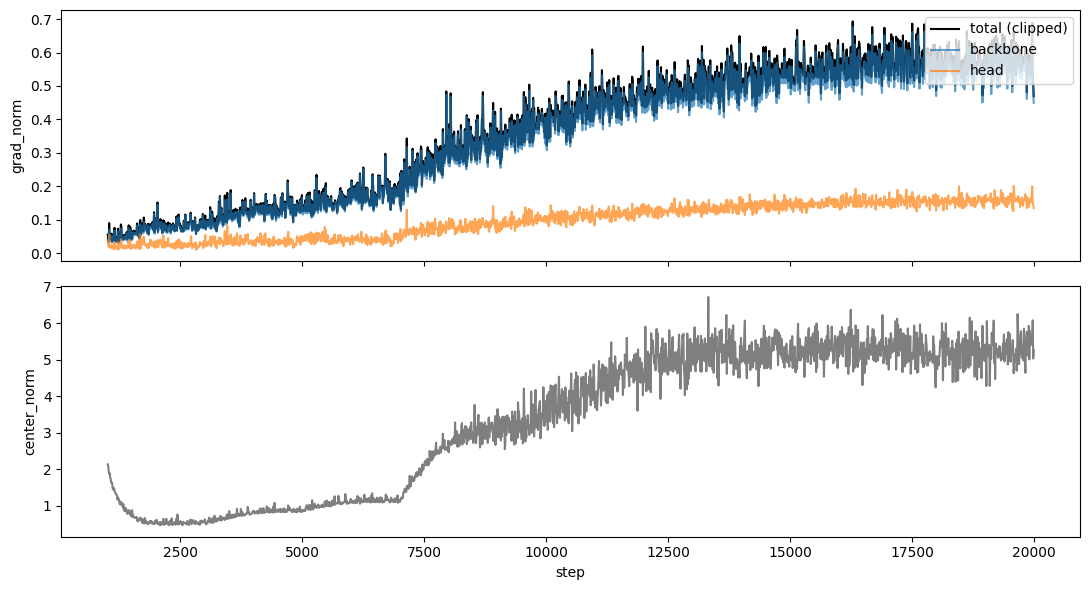

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(final["step"], final["grad_norm"], label="total (clipped)", color="black")
if "grad_norm_backbone" in final:
    axes[0].plot(final["step"], final["grad_norm_backbone"], label="backbone", alpha=0.7)
if "grad_norm_head" in final:
    axes[0].plot(final["step"], final["grad_norm_head"], label="head", alpha=0.7)
axes[0].set_ylabel("grad_norm")
axes[0].legend(loc="upper right")

axes[1].plot(final["step"], final["center_norm"], color="C7")
axes[1].set_ylabel("center_norm")
axes[1].set_xlabel("step")

plt.tight_layout()
plt.show()

## Windowed summary

Same rolling-window aggregation used throughout the manual checks: mean/min/max of the collapse-relevant metrics over fixed-size step windows, so a trend across thousands of steps is readable in one table instead of a noisy per-step plot.

In [9]:
WINDOW_STEPS = 1000  # adjust to taste

bins = pd.cut(final["step"], bins=range(int(final["step"].min()), int(final["step"].max()) + WINDOW_STEPS, WINDOW_STEPS))
summary = final.groupby(bins, observed=True).agg(
    loss_mean=("loss", "mean"),
    entropy_mean_avg=("teacher_entropy_mean", "mean"),
    entropy_min_avg=("teacher_entropy_min", "mean"),
    entropy_min_worst=("teacher_entropy_min", "min"),
    max_prob_avg=("teacher_max_prob", "mean"),
    max_prob_worst=("teacher_max_prob", "max"),
).round(3)
summary

,loss_mean,entropy_mean_avg,entropy_min_avg,entropy_min_worst,max_prob_avg,max_prob_worst
step,,,,,,
"(1010, 2010]",8.012,7.958,7.382,6.769,0.004,0.008
"(2010, 3010]",7.734,7.660,6.625,6.436,0.007,0.011
"(3010, 4010]",7.512,7.407,6.062,5.681,0.010,0.015
"(4010, 5010]",7.346,7.238,5.692,5.497,0.011,0.017
"(5010, 6010]",7.222,7.090,5.420,5.136,0.013,0.020
"(6010, 7010]",7.139,7.011,5.264,4.995,0.014,0.022
"(7010, 8010]",6.714,6.474,4.354,3.300,0.025,0.048
"(8010, 9010]",6.128,5.769,3.438,2.432,0.040,0.066
"(9010, 10010]",5.758,5.241,2.750,1.771,0.055,0.083


## Eval gates

Loads one or more `eval.json` snapshots (edit `EVAL_PATHS` above) and shows metrics + the gate table. Pass multiple paths (e.g. saved from successive checkpoints) to see gate progress over time in one table.

In [10]:
def load_eval(path: str) -> dict:
    with open(path) as f:
        return json.load(f)

evals = [load_eval(p) for p in EVAL_PATHS if Path(p).exists()]
missing = [p for p in EVAL_PATHS if not Path(p).exists()]
if missing:
    print("not found, skipped:", missing)

metrics_df = pd.DataFrame([e["metrics"] for e in evals], index=[Path(p).stem for p, e in zip(EVAL_PATHS, evals)])
metrics_df.T

,eval
probe_top1,0.538000
probe_macro_f1,0.100257
probe_majority_baseline,0.538600
dense_recall@10,0.012822
dense_recall@100,0.026233
dense_mrr,0.012407
bm25_recall@10,0.021394
bm25_recall@100,0.037944
bm25_mrr,0.021204
hybrid_recall@10,0.018423


In [11]:
gates_df = pd.DataFrame({
    Path(p).stem: {g["name"]: ("PASS" if g["passed"] else "FAIL") for g in e["gates"]}
    for p, e in zip(EVAL_PATHS, evals)
})

def highlight(v):
    color = "#c6f6d5" if v == "PASS" else "#fed7d7"
    return f"background-color: {color}"

gates_df.style.map(highlight)

,eval
cos_positive,PASS
cos_random,PASS
top10_jaccard,FAIL
probe_top1,FAIL
beats_bm25,FAIL
beats_hybrid_check,FAIL
stability,PASS
